In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load data
data = load_breast_cancer()
X, y = data.data, data.target

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data loaded successfully! Training shape:", X_train.shape)

Data loaded successfully! Training shape: (455, 30)


In [3]:
# Train a Random Forest with OOB scoring enabled
rf_oob = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
rf_oob.fit(X_train, y_train)

print(f"Train Accuracy: {accuracy_score(y_train, rf_oob.predict(X_train)):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, rf_oob.predict(X_test)):.4f}")
print(f"OOB Score:      {rf_oob.oob_score_:.4f}")


Train Accuracy: 1.0000
Test Accuracy:  0.9649
OOB Score:      0.9560


/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


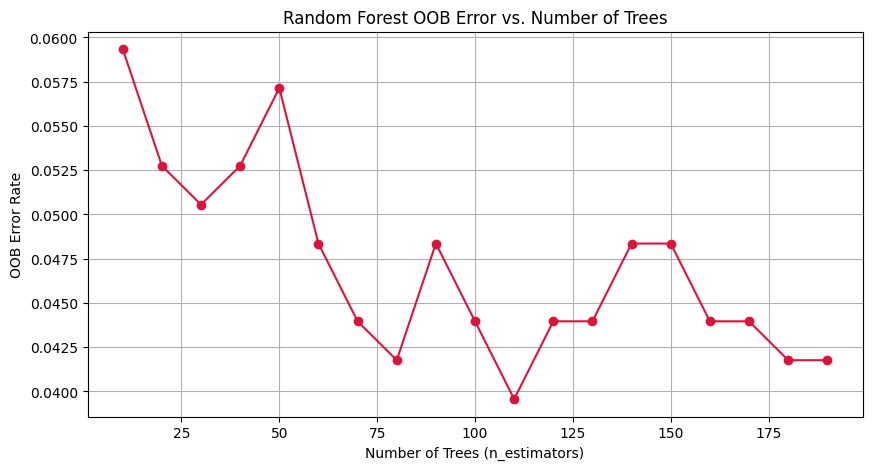

In [4]:
error_rates = []
tree_counts = range(10, 200, 10)

for n in tree_counts:
    rf = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    error_rates.append(1.0 - rf.oob_score_)

plt.figure(figsize=(10, 5))
plt.plot(tree_counts, error_rates, marker='o', color='crimson')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('OOB Error Rate')
plt.title('Random Forest OOB Error vs. Number of Trees')
plt.grid(True)
plt.show()

In [5]:
max_features_options = ['sqrt', 'log2', 1.0] # 1.0 means using all features (like standard bagging)

for opt in max_features_options:
    rf = RandomForestClassifier(n_estimators=100, max_features=opt, random_state=42)
    rf.fit(X_train, y_train)
    acc = accuracy_score(y_test, rf.predict(X_test))
    print(f"max_features: {opt} | Test Accuracy: {acc:.4f}")

max_features: sqrt | Test Accuracy: 0.9649
max_features: log2 | Test Accuracy: 0.9649
max_features: 1.0 | Test Accuracy: 0.9561
